<a href="https://colab.research.google.com/github/sohailpayami2023/digital-signal-processing-python/blob/main/notebooks/01_signal_fundamentals/02_matplotlib_plotting_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Matplotlib Plotting for Wireless and DSP Engineers

The notebook introduces:
- simple pyplot plotting
- object-oriented plotting (`fig`, `ax`, `axs`)
- colours, markers, and line styles
- legends and grids
- subplots
- subplot titles
- LaTeX-style formulas
- figure saving
- Google Colab figure downloading

The examples are intentionally simple and repetitive so you can easily experiment and modify them while learning.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Generate example signals

Fs = 1000  # Sampling frequency [Hz]

t = np.linspace(0, 1, Fs)

x1 = np.sin(2 * np.pi * 5 * t)

x2 = 0.7 * np.cos(2 * np.pi * 10 * t)



# 1. Simple Pyplot Style

This is the simpler MATLAB-like plotting style.

Matplotlib internally keeps track of the "current figure" and "current axes".

This style is convenient for:
- quick experiments
- simple one-off plots
- short scripts


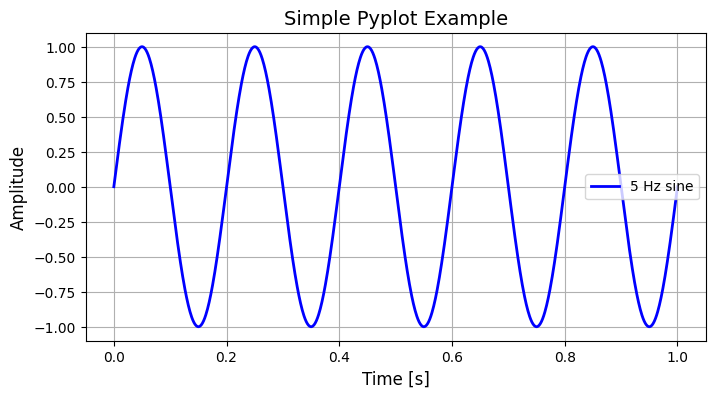

In [2]:

plt.figure(figsize=(8, 4))

plt.plot(
    t,
    x1,
    color='blue',
    linewidth=2,
    label='5 Hz sine'
)

plt.xlabel('Time [s]', fontsize=12)

plt.ylabel('Amplitude', fontsize=12)

plt.title('Simple Pyplot Example', fontsize=14)

plt.grid(True)

plt.legend(fontsize=10)

plt.show()



# 2. Common Styling Options

You can control:
- colour
- line style
- marker type
- marker size
- line width
- font size

## Common colours

| Colour | Code |
|---|---|
| `'blue'` | `'b'` |
| `'red'` | `'r'` |
| `'green'` | `'g'` |
| `'black'` | `'k'` |
| `'magenta'` | `'m'` |
| `'cyan'` | `'c'` |

## Common line styles

| Style | Meaning |
|---|---|
| `'-'` | solid |
| `'--'` | dashed |
| `':'` | dotted |
| `'-.'` | dash-dot |

## Common markers

| Marker | Meaning |
|---|---|
| `'.'` | point |
| `'o'` | circle |
| `'x'` | x marker |
| `'+'` | plus |
| `'*'` | star |
| `'s'` | square |

## Font size examples

| Parameter | Example |
|---|---|
| axis label | `fontsize=12` |
| title | `fontsize=14` |
| legend | `fontsize=10` |


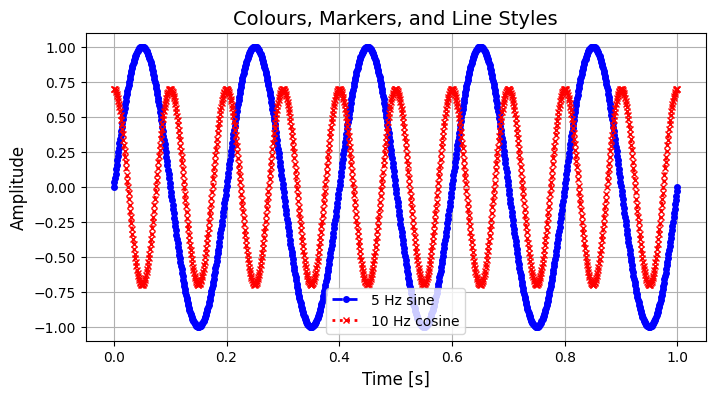

In [3]:

plt.figure(figsize=(8, 4))

plt.plot(
    t,
    x1,
    color='blue',
    linestyle='--',
    linewidth=2,
    marker='o',
    markersize=4,
    label='5 Hz sine'
)

plt.plot(
    t,
    x2,
    color='red',
    linestyle=':',
    linewidth=2,
    marker='x',
    markersize=5,
    label='10 Hz cosine'
)

plt.xlabel('Time [s]', fontsize=12)

plt.ylabel('Amplitude', fontsize=12)

plt.title('Colours, Markers, and Line Styles', fontsize=14)

plt.grid(True)

plt.legend(fontsize=10)

plt.show()



# 3. Object-Oriented Plotting Style

The object-oriented (OO) approach gives more explicit control over plots.

This becomes especially useful when working with:
- subplots
- complex layouts
- larger plotting scripts

## Why do we write `fig, ax = plt.subplots()`?

`plt.subplots()` returns:

- `fig` → the whole figure
- `ax` → the plotting axes

Even if `fig` is not used immediately, it is often kept because later we may want:

```python
fig.tight_layout()
fig.savefig(...)
fig.suptitle(...)
```

If you truly do not need the figure object:

```python
_, ax = plt.subplots()
```

The underscore `_` is a Python convention meaning:

> "I intentionally do not need this variable."


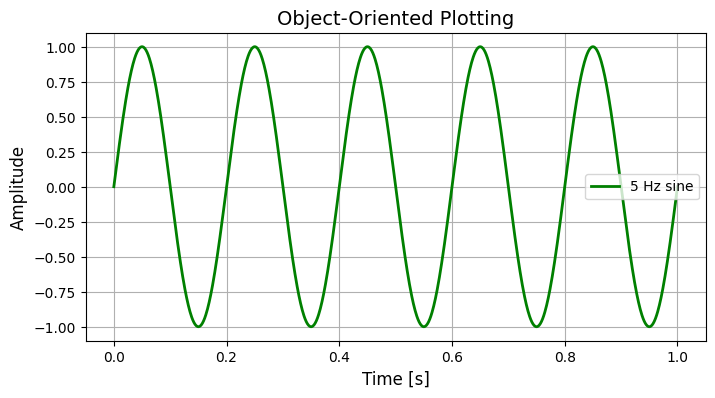

In [4]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    t,
    x1,
    color='green',
    linewidth=2,
    label='5 Hz sine'
)

ax.set_xlabel('Time [s]', fontsize=12)

ax.set_ylabel('Amplitude', fontsize=12)

ax.set_title('Object-Oriented Plotting', fontsize=14)

ax.grid(True)

ax.legend(fontsize=10)

plt.show()



# 4. Multiple Curves on the Same Plot

Unlike MATLAB, Matplotlib does NOT require `hold on`.

You simply call `plot()` multiple times.


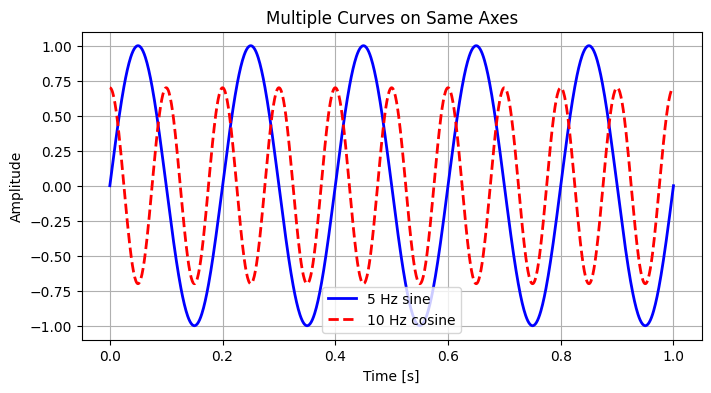

In [5]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    t,
    x1,
    color='blue',
    linewidth=2,
    label='5 Hz sine'
)

ax.plot(
    t,
    x2,
    color='red',
    linestyle='--',
    linewidth=2,
    label='10 Hz cosine'
)

ax.set_xlabel('Time [s]')

ax.set_ylabel('Amplitude')

ax.set_title('Multiple Curves on Same Axes')

ax.grid(True)

ax.legend()

plt.show()



# 5. Subplots

Subplots allow multiple plots inside the same figure.

## `sharex=True`

`sharex=True` makes all subplots use the same x-axis.

Useful when plotting signals that share the same:
- time axis
- frequency axis

Zooming/panning one subplot also affects the others.


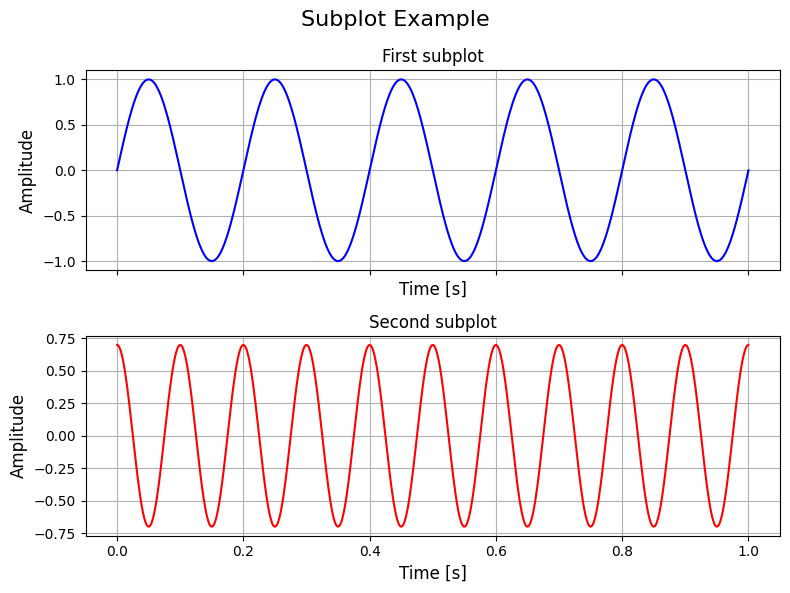

In [6]:

# sharex=True makes subplots share the same x-axis

fig, axs = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True
)

# Main title for whole figure
fig.suptitle('Subplot Example', fontsize=16)

axs[0].plot(
    t,
    x1,
    color='blue'
)

axs[0].set_title('First subplot')

axs[1].plot(
    t,
    x2,
    color='red'
)

axs[1].set_title('Second subplot')

# axs.flat allows looping through all subplots one-by-one
for ax in axs.flat:

    ax.set_xlabel('Time [s]', fontsize=12)

    ax.set_ylabel('Amplitude', fontsize=12)

    ax.grid(True)

# Automatically adjusts spacing so labels/titles do not overlap
fig.tight_layout()

plt.show()



# 6. LaTeX-Style Mathematical Formulas

Matplotlib supports LaTeX-style math text using:

```python
r'$ ... $'
```

Examples:

| Formula | Python |
|---|---|
| \(x(t)=\sin(2\pi f_0 t)\) | `r'$x(t)=\sin(2\pi f_0 t)$'` |
| \(f_s\) | `r'$f_s$'` |
| \(\Delta f=f_s/N\) | `r'$\Delta f=f_s/N$'` |


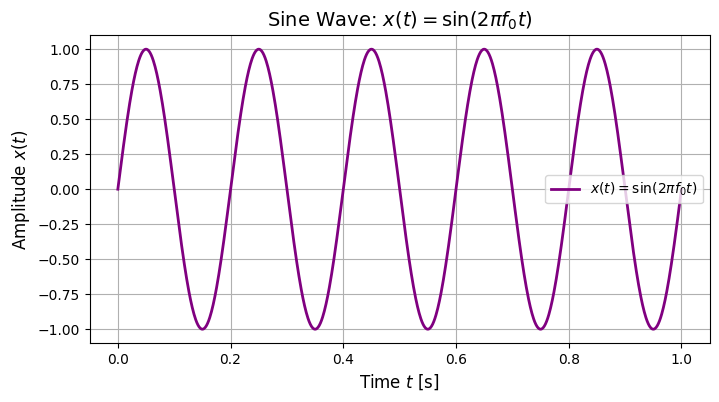

In [7]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    t,
    x1,
    color='purple',
    linewidth=2,
    label=r'$x(t)=\sin(2\pi f_0 t)$'
)

ax.set_title(
    r'Sine Wave: $x(t)=\sin(2\pi f_0 t)$',
    fontsize=14
)

ax.set_xlabel(r'Time $t$ [s]', fontsize=12)

ax.set_ylabel(r'Amplitude $x(t)$', fontsize=12)

ax.grid(True)

ax.legend(fontsize=10)

plt.show()



# 7. Saving Figures

You can save plots using:

```python
fig.savefig('plot.png')
```

Common formats:
- PNG
- JPG
- PDF
- SVG

Higher `dpi` gives higher image quality.


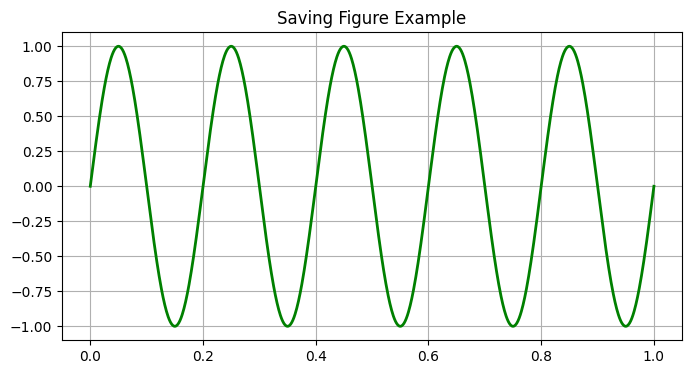

In [8]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    t,
    x1,
    color='green',
    linewidth=2
)

ax.set_title('Saving Figure Example')

ax.grid(True)

# Save figure to current working folder
fig.savefig(
    'example_plot.png',
    dpi=300
)

plt.show()



# 8. Saving and Downloading Figures in Google Colab

The saving process is almost the same in Google Colab:

```python
fig.savefig('plot.png')
```

However, Colab runs on a remote machine.

So after saving, you usually download the file manually.


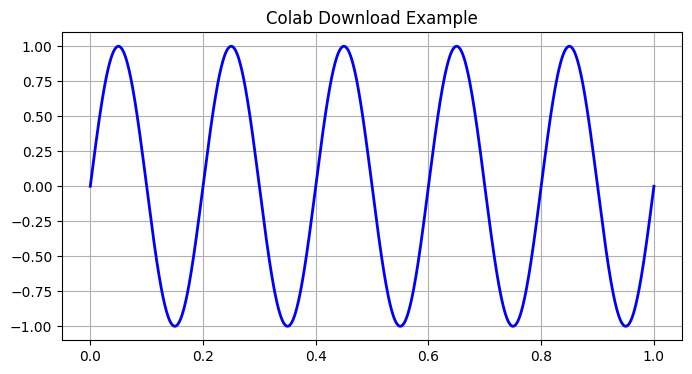

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:

# Google Colab example

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    t,
    x1,
    color='blue',
    linewidth=2
)

ax.set_title('Colab Download Example')

ax.grid(True)

# Save image
fig.savefig('colab_plot.png', dpi=300)

plt.show()

# In Google Colab, download using:
#
# from google.colab import files
#
# files.download('colab_plot.png')
#
# This downloads the saved image to your computer.
